            Each week, you will apply the concepts of that week to your Integrated Capstone Project's dataset. In preparation for Milestone One, create a Jupyter Notebook that illustrates these lessons. There are no specific questions to answer in this notebook; the goal is to analyze the data using this week's methods and draw useful conclusions.

            For Week 5, the focus is support vector machines. This notebook compares linear and radial basis function (RBF) SVMs on the Wisconsin and Brazil cancer datasets, using standardized features and ROC-AUC-driven tuning.
            


In [10]:
            from pathlib import Path
            import sys

            PROJECT_ROOT = Path.cwd().resolve().parents[1]
            if str(PROJECT_ROOT) not in sys.path:
                sys.path.append(str(PROJECT_ROOT))

            PROJECT_ROOT
            


PosixPath('/Users/jamieconner/projects/bu/dx799_01/mod_c_capstone')

## Imports


In [11]:
            import warnings

            import matplotlib.pyplot as plt
            import pandas as pd
            from sklearn.exceptions import ConvergenceWarning
            from sklearn.metrics import (
                accuracy_score,
                average_precision_score,
                f1_score,
                precision_score,
                recall_score,
                roc_auc_score,
            )
            from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
            from sklearn.pipeline import Pipeline
            from sklearn.preprocessing import StandardScaler
            from sklearn.svm import SVC

            from src.load_data import load_brazil, load_wisconsin, split_X_y

            warnings.filterwarnings("ignore", category=ConvergenceWarning)
            plt.style.use("seaborn-v0_8-whitegrid")
            pd.set_option("display.max_colwidth", 80)
            RANDOM_STATE = 42
            


            ## Wisconsin dataset

            Wisconsin is small, clean, and pretty separable, so I wanted to see whether an RBF kernel actually added anything over a simpler linear SVM once the features were scaled.
            


In [12]:
            df_w, target_w = load_wisconsin()
            X_w, y_w = split_X_y(df_w, target_w)

            Xw_train, Xw_test, yw_train, yw_test = train_test_split(
                X_w,
                y_w,
                test_size=0.2,
                stratify=y_w,
                random_state=RANDOM_STATE,
            )

            print("Wisconsin shape:", X_w.shape)
            print("Positive class rate:", round(y_w.mean(), 3))
            


Wisconsin shape: (569, 30)
Positive class rate: 0.373


In [13]:
            wisconsin_rows = []

            wisconsin_linear_pipe = Pipeline(
                [
                    ("scaler", StandardScaler()),
                    ("model", SVC(kernel="linear", probability=True, random_state=RANDOM_STATE)),
                ]
            )
            wisconsin_linear_search = GridSearchCV(
                wisconsin_linear_pipe,
                {"model__C": [0.1, 1, 10]},
                scoring="roc_auc",
                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                n_jobs=-1,
            )
            wisconsin_linear_search.fit(Xw_train, yw_train)

            wisconsin_linear_pred = wisconsin_linear_search.best_estimator_.predict(Xw_test)
            wisconsin_linear_score = wisconsin_linear_search.best_estimator_.predict_proba(Xw_test)[:, 1]

            wisconsin_rows.append(
                {
                    "dataset": "Wisconsin",
                    "kernel": "linear",
                    "accuracy": accuracy_score(yw_test, wisconsin_linear_pred),
                    "precision": precision_score(yw_test, wisconsin_linear_pred),
                    "recall": recall_score(yw_test, wisconsin_linear_pred),
                    "f1": f1_score(yw_test, wisconsin_linear_pred),
                    "roc_auc": roc_auc_score(yw_test, wisconsin_linear_score),
                    "pr_auc": average_precision_score(yw_test, wisconsin_linear_score),
                    "cv_roc_auc": wisconsin_linear_search.best_score_,
                    "predicted_positive_rate": wisconsin_linear_pred.mean(),
                    "best_params": wisconsin_linear_search.best_params_,
                }
            )

            wisconsin_rbf_pipe = Pipeline(
                [
                    ("scaler", StandardScaler()),
                    ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
                ]
            )
            wisconsin_rbf_search = GridSearchCV(
                wisconsin_rbf_pipe,
                {"model__C": [1, 10], "model__gamma": ["scale", 0.01]},
                scoring="roc_auc",
                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                n_jobs=-1,
            )
            wisconsin_rbf_search.fit(Xw_train, yw_train)

            wisconsin_rbf_pred = wisconsin_rbf_search.best_estimator_.predict(Xw_test)
            wisconsin_rbf_score = wisconsin_rbf_search.best_estimator_.predict_proba(Xw_test)[:, 1]

            wisconsin_rows.append(
                {
                    "dataset": "Wisconsin",
                    "kernel": "rbf",
                    "accuracy": accuracy_score(yw_test, wisconsin_rbf_pred),
                    "precision": precision_score(yw_test, wisconsin_rbf_pred),
                    "recall": recall_score(yw_test, wisconsin_rbf_pred),
                    "f1": f1_score(yw_test, wisconsin_rbf_pred),
                    "roc_auc": roc_auc_score(yw_test, wisconsin_rbf_score),
                    "pr_auc": average_precision_score(yw_test, wisconsin_rbf_score),
                    "cv_roc_auc": wisconsin_rbf_search.best_score_,
                    "predicted_positive_rate": wisconsin_rbf_pred.mean(),
                    "best_params": wisconsin_rbf_search.best_params_,
                }
            )

            wisconsin_results = pd.DataFrame(wisconsin_rows)
            wisconsin_results.round(4)
            


,dataset,kernel,accuracy,precision,recall,f1,roc_auc,pr_auc,cv_roc_auc,predicted_positive_rate,best_params
0,Wisconsin,linear,0.9825,1.0,0.9524,0.9756,0.9964,0.9951,0.9944,0.3509,{'model__C': 0.1}
1,Wisconsin,rbf,0.9825,1.0,0.9524,0.9756,0.9960,0.9947,0.9954,0.3509,"{'model__C': 10, 'model__gamma': 0.01}"


            Wisconsin ended up being almost too easy. After scaling, both kernels performed nearly the same on the test set, which suggests the classes were already very well separated.
            


            ## Brazil dataset

            Brazil is much larger and much more imbalanced, so I used an 8,000-row sample to keep the notebook runnable and paid more attention to ROC-AUC, PR-AUC, precision, and recall than to accuracy alone.
            


In [14]:
            df_b, target_b = load_brazil(sample_size=8000, random_state=RANDOM_STATE)
            X_b, y_b = split_X_y(df_b, target_b)

            Xb_train, Xb_test, yb_train, yb_test = train_test_split(
                X_b,
                y_b,
                test_size=0.2,
                stratify=y_b,
                random_state=RANDOM_STATE,
            )

            print("Brazil sample shape:", X_b.shape)
            print("Positive class rate:", round(y_b.mean(), 3))
            


Brazil sample shape: (8000, 39)
Positive class rate: 0.07


In [15]:
            brazil_rows = []

            brazil_linear_pipe = Pipeline(
                [
                    ("scaler", StandardScaler()),
                    ("model", SVC(kernel="linear", probability=True, random_state=RANDOM_STATE)),
                ]
            )
            brazil_linear_search = GridSearchCV(
                brazil_linear_pipe,
                {"model__C": [0.1, 1]},
                scoring="roc_auc",
                cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
                n_jobs=-1,
            )
            brazil_linear_search.fit(Xb_train, yb_train)

            brazil_linear_pred = brazil_linear_search.best_estimator_.predict(Xb_test)
            brazil_linear_score = brazil_linear_search.best_estimator_.predict_proba(Xb_test)[:, 1]

            brazil_rows.append(
                {
                    "dataset": "Brazil",
                    "kernel": "linear",
                    "accuracy": accuracy_score(yb_test, brazil_linear_pred),
                    "precision": precision_score(yb_test, brazil_linear_pred, zero_division=0),
                    "recall": recall_score(yb_test, brazil_linear_pred, zero_division=0),
                    "f1": f1_score(yb_test, brazil_linear_pred, zero_division=0),
                    "roc_auc": roc_auc_score(yb_test, brazil_linear_score),
                    "pr_auc": average_precision_score(yb_test, brazil_linear_score),
                    "cv_roc_auc": brazil_linear_search.best_score_,
                    "predicted_positive_rate": brazil_linear_pred.mean(),
                    "best_params": brazil_linear_search.best_params_,
                }
            )

            brazil_rbf_pipe = Pipeline(
                [
                    ("scaler", StandardScaler()),
                    ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
                ]
            )
            brazil_rbf_search = GridSearchCV(
                brazil_rbf_pipe,
                {"model__C": [1], "model__gamma": ["scale", 0.01]},
                scoring="roc_auc",
                cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
                n_jobs=-1,
            )
            brazil_rbf_search.fit(Xb_train, yb_train)

            brazil_rbf_pred = brazil_rbf_search.best_estimator_.predict(Xb_test)
            brazil_rbf_score = brazil_rbf_search.best_estimator_.predict_proba(Xb_test)[:, 1]

            brazil_rows.append(
                {
                    "dataset": "Brazil",
                    "kernel": "rbf",
                    "accuracy": accuracy_score(yb_test, brazil_rbf_pred),
                    "precision": precision_score(yb_test, brazil_rbf_pred, zero_division=0),
                    "recall": recall_score(yb_test, brazil_rbf_pred, zero_division=0),
                    "f1": f1_score(yb_test, brazil_rbf_pred, zero_division=0),
                    "roc_auc": roc_auc_score(yb_test, brazil_rbf_score),
                    "pr_auc": average_precision_score(yb_test, brazil_rbf_score),
                    "cv_roc_auc": brazil_rbf_search.best_score_,
                    "predicted_positive_rate": brazil_rbf_pred.mean(),
                    "best_params": brazil_rbf_search.best_params_,
                }
            )

            brazil_results = pd.DataFrame(brazil_rows)
            brazil_results.round(4)
            


,dataset,kernel,accuracy,precision,recall,f1,roc_auc,pr_auc,cv_roc_auc,predicted_positive_rate,best_params
0,Brazil,linear,0.9444,0.7143,0.3540,0.4734,0.8779,0.4584,0.9100,0.0350,{'model__C': 1}
1,Brazil,rbf,0.9462,0.7647,0.3451,0.4756,0.9330,0.5607,0.9249,0.0319,"{'model__C': 1, 'model__gamma': 0.01}"


            Brazil was more informative. Accuracy stayed high for both kernels, but the recall numbers show that the model still misses a lot of the minority deceased cases at the default threshold.
            


## Combined comparison


In [16]:
            svm_results = pd.concat([wisconsin_results, brazil_results], ignore_index=True)
            svm_results.round(4)
            


,dataset,kernel,accuracy,precision,recall,f1,roc_auc,pr_auc,cv_roc_auc,predicted_positive_rate,best_params
0,Wisconsin,linear,0.9825,1.0000,0.9524,0.9756,0.9964,0.9951,0.9944,0.3509,{'model__C': 0.1}
1,Wisconsin,rbf,0.9825,1.0000,0.9524,0.9756,0.9960,0.9947,0.9954,0.3509,"{'model__C': 10, 'model__gamma': 0.01}"
2,Brazil,linear,0.9444,0.7143,0.3540,0.4734,0.8779,0.4584,0.9100,0.0350,{'model__C': 1}
3,Brazil,rbf,0.9462,0.7647,0.3451,0.4756,0.9330,0.5607,0.9249,0.0319,"{'model__C': 1, 'model__gamma': 0.01}"


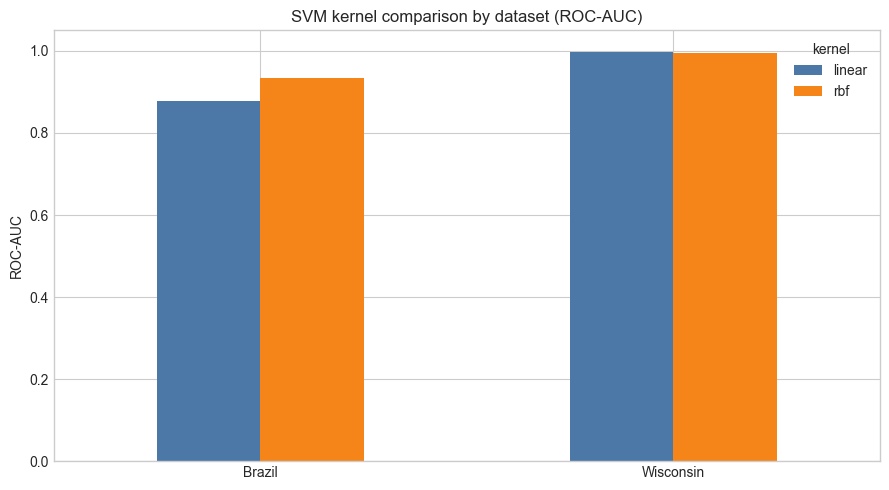

In [17]:
            roc_plot = svm_results.pivot(index="dataset", columns="kernel", values="roc_auc")
            ax = roc_plot.plot(kind="bar", figsize=(9, 5), color=["#4c78a8", "#f58518"], rot=0)
            ax.set_title("SVM kernel comparison by dataset (ROC-AUC)")
            ax.set_ylabel("ROC-AUC")
            ax.set_xlabel("")
            ax.set_ylim(0, 1.05)
            plt.tight_layout()
            plt.show()
            


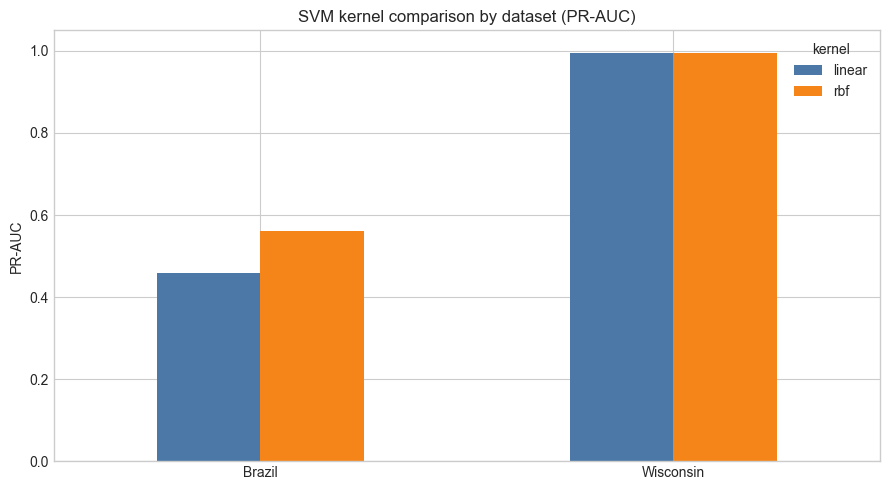

In [18]:
            pr_plot = svm_results.pivot(index="dataset", columns="kernel", values="pr_auc")
            ax = pr_plot.plot(kind="bar", figsize=(9, 5), color=["#4c78a8", "#f58518"], rot=0)
            ax.set_title("SVM kernel comparison by dataset (PR-AUC)")
            ax.set_ylabel("PR-AUC")
            ax.set_xlabel("")
            ax.set_ylim(0, 1.05)
            plt.tight_layout()
            plt.show()
            


            ## Week 5 takeaway

            For Wisconsin, SVM worked very well but the nonlinear kernel did not really buy much. Linear and RBF SVMs both separated the classes extremely well once the features were standardized.

            For Brazil, the RBF kernel helped more, especially on ROC-AUC and PR-AUC, which suggests some nonlinear structure in the larger and messier dataset. At the same time, recall stayed fairly modest, so this was another reminder that accuracy alone can make the Brazil results look better than they really are.
            
